Starting training loop...
Epoch [1/30] - Current Loss: 0.6984
Epoch [5/30] - Current Loss: 0.3921
Epoch [10/30] - Current Loss: 0.1276
Epoch [15/30] - Current Loss: 0.0264
Epoch [20/30] - Current Loss: 0.0065
Epoch [25/30] - Current Loss: 0.0024
Epoch [30/30] - Current Loss: 0.0012

Training Complete. Generating loss curve...


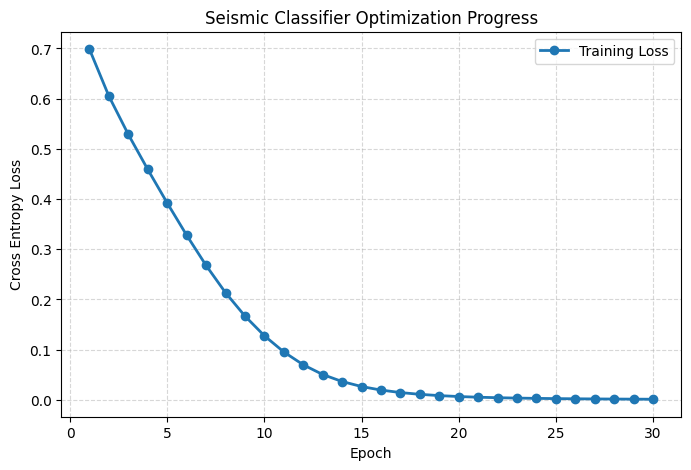

File successfully saved as 'step3_loss_curve.png'


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt  

#Defining a 1D CNN Architecture suitable for dense DAS arrays or geophone data
class SeismicClassifier(nn.Module):
    def __init__(self):
        super(SeismicClassifier, self).__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=15, stride=2, padding=7),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            nn.Conv1d(16, 32, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)  # to flatten down the time dimension
        )
        self.classifier = nn.Linear(32, 2) # Binary Classification: 0 = Traffic Noise, 1 = Hazard

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

#Instantiating dummy data mimicking a continuous wave (Batch Size = 4, Channels = 1, Time Samples = 1000)
dummy_seismic_stream = torch.randn(4, 1, 1000)
labels = torch.tensor([0, 1, 0, 1], dtype=torch.long)

model = SeismicClassifier()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01) # Bumped learning rate slightly for faster toy convergence

#Simulating a multi-epoch training loop to gather historical data for the curve
num_epochs = 30
loss_history = []

print("Starting training loop...")
for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = model(dummy_seismic_stream)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    
    # to store the loss scalar value
    loss_history.append(loss.item())
    
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] - Current Loss: {loss.item():.4f}")

print("\nTraining Complete. Generating loss curve...")

#Plotting and saving the execution outputs
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), loss_history, marker='o', color='#1f77b4', linewidth=2, label='Training Loss')
plt.title('Seismic Classifier Optimization Progress')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

plt.savefig('step3_loss_curve.png', dpi=300, bbox_inches='tight')
plt.close()

print("File successfully saved as 'step3_loss_curve.png'")